Field: AI / ML | Task: Stroke Prediction (Binary Classification)

Dataset Loaded Successfully! Shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0  

C:\Users\BURRAQ LAPTOPS\AppData\Local\Temp\ipykernel_3132\1461469036.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


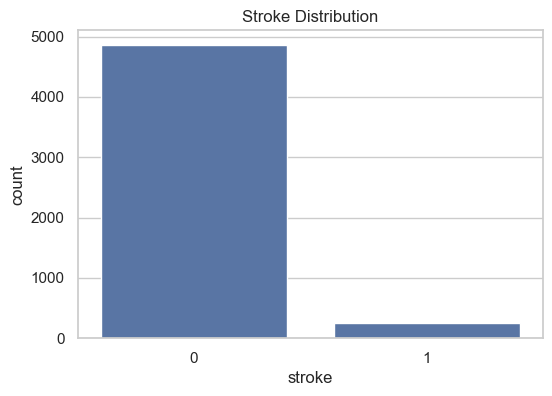

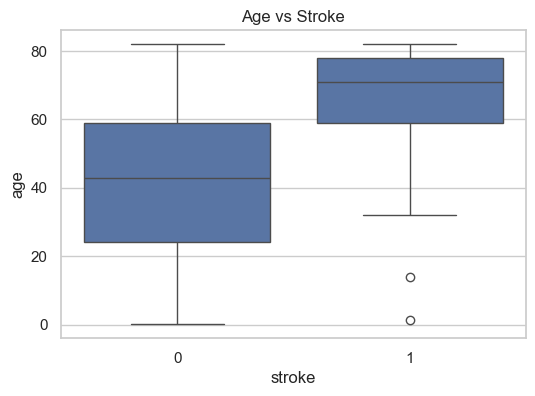

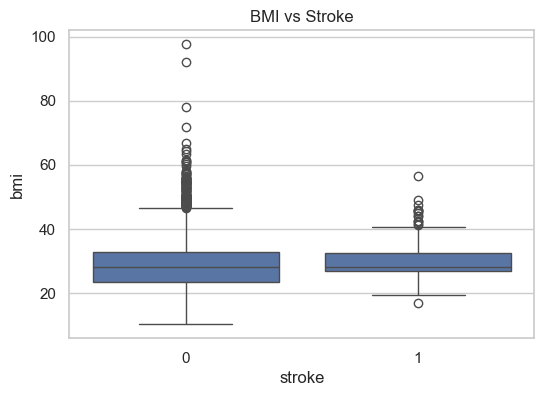

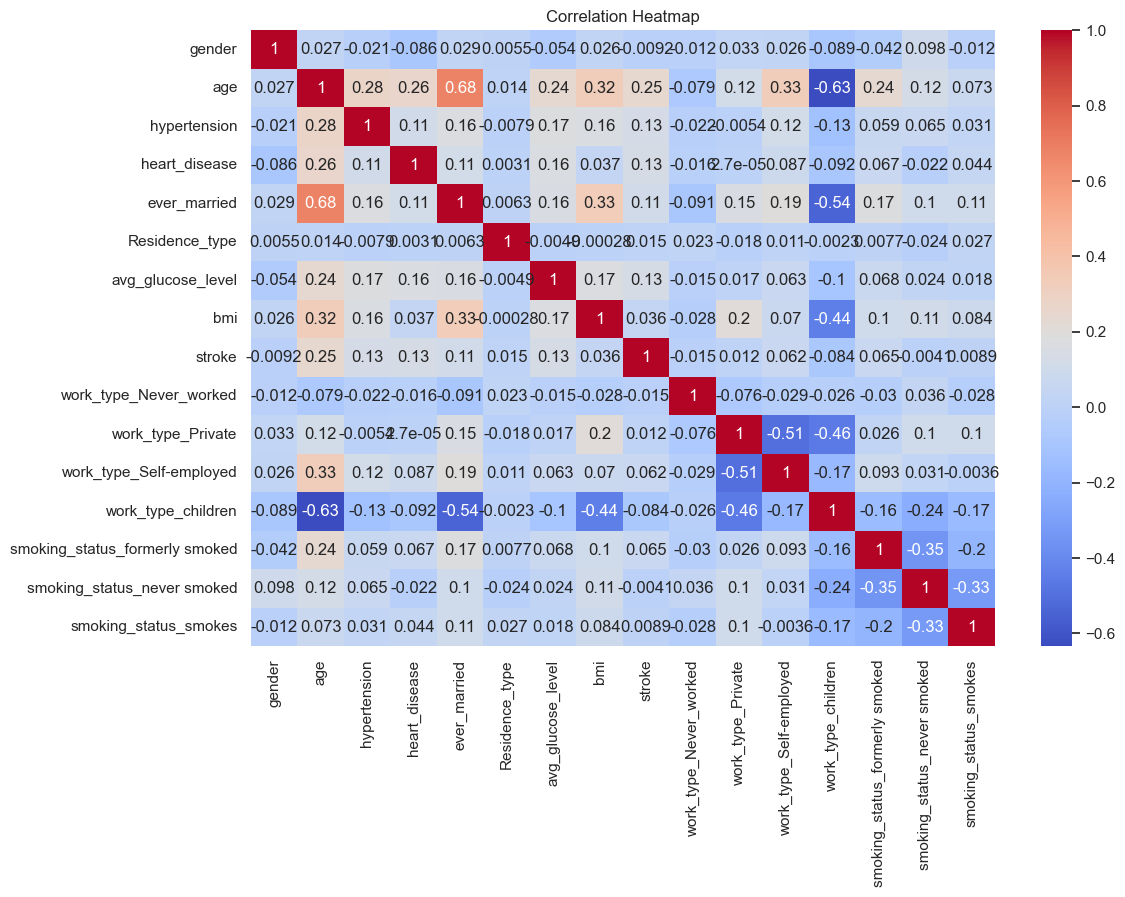

Features: Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='object') 

Class counts after balancing:
stroke
1    4861
0    4861
Name: count, dtype: int64 

Normalization Done!

Training samples: 7777
Testing samples: 1945 

Model Training Completed!

--- Random Forest Evaluation ---
Accuracy: 0.9563
Precision: 0.9576
Recall: 0.9546
F1 Score: 0.9561


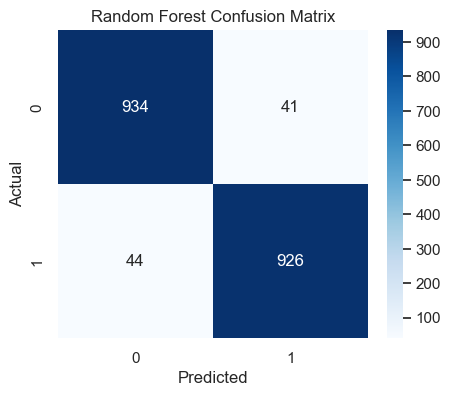

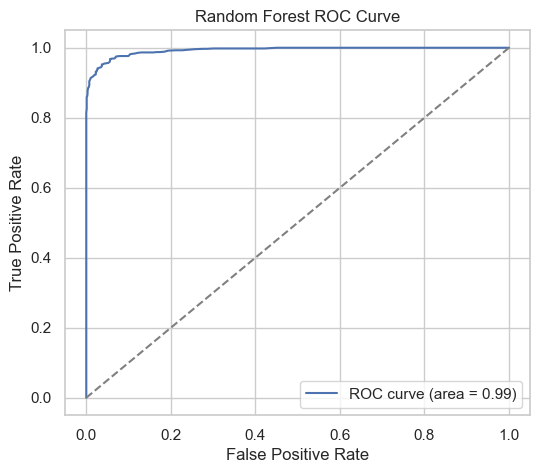



--- Logistic Regression Evaluation ---
Accuracy: 0.8535
Precision: 0.8549
Recall: 0.8505
F1 Score: 0.8527


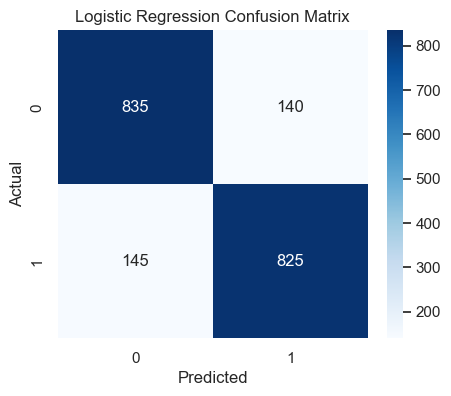

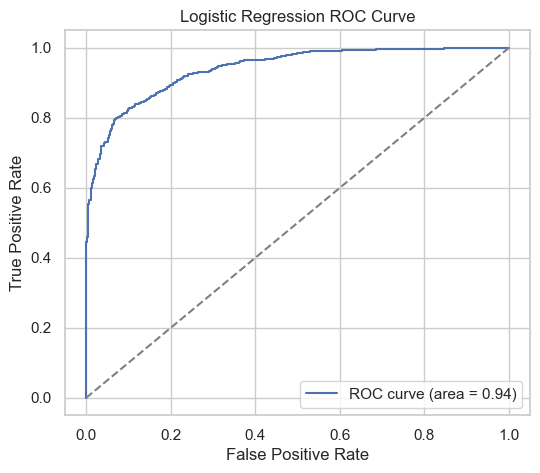



Models and Scaler Saved Successfully!

Sample Patient Prediction (Random Forest): 0


In [1]:
# ------------------- 0. Libraries -------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import joblib

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# ------------------- 1. Field & Topic -------------------
print("Field: AI / ML | Task: Stroke Prediction (Binary Classification)\n")

# ------------------- 2. Load Dataset -------------------
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Dataset Loaded Successfully! Shape:", df.shape)
print(df.head(), "\n")

# ------------------- 3. Preprocessing -------------------
# Drop ID
df.drop('id', axis=1, inplace=True)

# Fill missing bmi
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Encode categorical features
df['gender'] = df['gender'].map({'Male':0,'Female':1,'Other':2})
df['ever_married'] = df['ever_married'].map({'Yes':1,'No':0})
df['Residence_type'] = df['Residence_type'].map({'Urban':1,'Rural':0})
df = pd.get_dummies(df, columns=['work_type','smoking_status'], drop_first=True)

print("Preprocessing Done!\n")

# ------------------- 4. EDA -------------------
print("Stroke Distribution:")
print(df['stroke'].value_counts(), "\n")

plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("BMI vs Stroke")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ------------------- 5. Feature Selection -------------------
X = df.drop('stroke', axis=1)
y = df['stroke']
print("Features:", X.columns, "\n")

# ------------------- 6. Handle Imbalance -------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print("Class counts after balancing:")
print(pd.Series(y_res).value_counts(), "\n")

# ------------------- 7. Normalization -------------------
num_features = ['age','avg_glucose_level','bmi']
scaler = StandardScaler()
X_res[num_features] = scaler.fit_transform(X_res[num_features])
print("Normalization Done!\n")

# ------------------- 8. Train-Test Split -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0], "\n")

# ------------------- 9. Model Training -------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Model Training Completed!\n")

# ------------------- 10. Evaluation Function -------------------
def evaluate(model, X_test, y_test, name="Model"):
    print(f"--- {name} Evaluation ---")
    y_pred = model.predict(X_test)
    print("Accuracy:", round(accuracy_score(y_test, y_pred),4))
    print("Precision:", round(precision_score(y_test, y_pred),4))
    print("Recall:", round(recall_score(y_test, y_pred),4))
    print("F1 Score:", round(f1_score(y_test, y_pred),4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()
    print("\n")

# ------------------- 11. Evaluate Models -------------------
evaluate(rf_model, X_test, y_test, "Random Forest")
evaluate(lr_model, X_test, y_test, "Logistic Regression")

# ------------------- 12. Save Models -------------------
joblib.dump(rf_model, "stroke_rf_model.pkl")
joblib.dump(lr_model, "stroke_lr_model.pkl")
joblib.dump(scaler, "stroke_scaler.pkl")
print("Models and Scaler Saved Successfully!\n")

# ------------------- 13. Demo Prediction -------------------
sample = X_test.iloc[0:1].copy()
sample[num_features] = scaler.transform(sample[num_features])
pred = rf_model.predict(sample)
print("Sample Patient Prediction (Random Forest):", pred[0])
